In [108]:
import galevo as galevo
import numpy as np
import matplotlib.pyplot as plt

Log_SFR = 3
SFEN = 150
location = 0
skewness = 0
sfr_tail = 0
# galevo.generate_SFH('skewnorm',  Log_SFR, SFEN, sfr_tail, skewness, location)
# galevo.generate_SFH('flat',  Log_SFR, SFEN, sfr_tail, skewness, location)
# galevo.generate_SFH('flat_tail',  Log_SFR, SFEN, sfr_tail, skewness, location)
galevo.generate_sfh_lognorm(3, 150)


In [138]:
def generate_sfh_that_is_lognorm(Log_SFR, SFEN):
    tot_sf_set = 10 ** Log_SFR * SFEN
    time_length_in_Gyr = 13
    time_step_number = time_length_in_Gyr * 100

    from scipy.stats import lognorm
    s = 1
    sc = SFEN / 2
    time_list = np.linspace(0, time_step_number, time_step_number)
    star_formation_rate = tot_sf_set * lognorm.pdf(time_list, s, scale=sc)

    for i in range (1300):
        if star_formation_rate[i] != 0:
            star_formation_rate[i] = np.log10(star_formation_rate[i])
    return star_formation_rate


data_lognorm_trial = generate_sfh_that_is_lognorm(3, 150)
print(data_lognorm_trial)

[ 0.          0.73033255  1.62443528 ... -0.10140145 -0.1026906
 -0.10397902]


In [150]:
def generate_sfh_that_is_skewnorm(Log_SFR, SFEN):
    tot_sf_set = 10 ** Log_SFR * SFEN
    time_length_in_Gyr = 13
    time_step_number = time_length_in_Gyr * 100

    from scipy.stats import skewnorm
    a = 1
    sc = SFEN / 2
    time_list = np.linspace(0, time_step_number, time_step_number)
    star_formation_rate = tot_sf_set * skewnorm.pdf(time_list, a, scale=sc)

    for i in range (1300):
        if star_formation_rate[i] != 0:
            star_formation_rate[i] = np.log10(star_formation_rate[i])
    return star_formation_rate


data_skewnorm_trial = generate_sfh_that_is_skewnorm(3, 150)
print(data_lognorm_trial)

[ 0.          0.73033255  1.62443528 ... -0.10140145 -0.1026906
 -0.10397902]


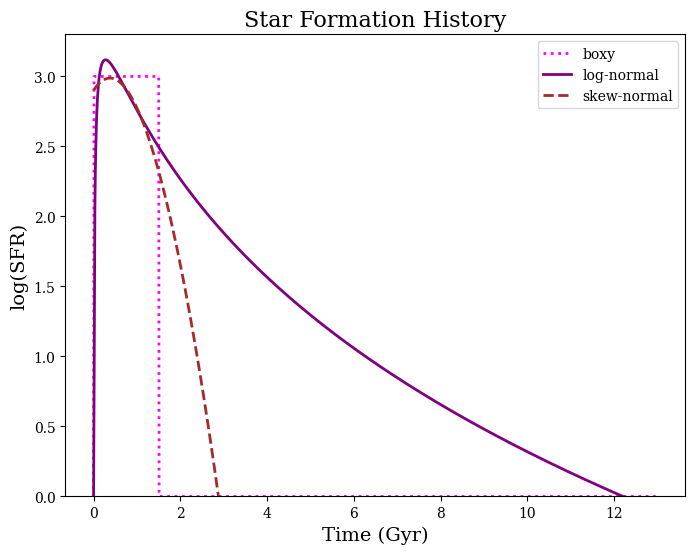

In [151]:
plt.figure(figsize=(8, 6))
plt.rc('font', family='serif')

data_flat = np.loadtxt("/Users/adriana_work/Desktop/galIMF/SFH_flat.txt", dtype=int)
data_lognorm = np.loadtxt("/Users/adriana_work/Desktop/galIMF/SFH_lognorm.txt", dtype=int)
data_skewnorm = np.loadtxt("/Users/adriana_work/Desktop/galIMF/SFH_skewnorm.txt", dtype=int)

for i in range (1300):
    if data_flat[i] != 0:
        data_flat[i] = np.log10(data_flat[i])
    if data_lognorm[i] != 0:
        data_lognorm[i] = np.log10(data_lognorm[i])
x_axis = np.arange(0,13,0.01)
plt.plot(x_axis, data_flat[:1300], lw=2, color="magenta", linestyle='dotted', label='boxy')
plt.plot(x_axis, data_lognorm_trial[:1300], lw=2, color="purple", label='log-normal')
plt.plot(x_axis, data_skewnorm_trial[:1300], lw=2, color="brown", linestyle='--', label='skew-normal')
plt.xlabel('Time (Gyr)', fontsize=14)
plt.ylabel('log(SFR)', fontsize=14)
plt.ylim(0,3.3)
plt.title('Star Formation History', fontsize=16)
plt.legend()
plt.savefig('/Users/adriana_work/Desktop/galIMF/figs/sfh_models_comparison.pdf', bbox_inches='tight', dpi=300)

[0.00000000e+00 1.00076982e+00 2.00153965e+00 ... 1.29799846e+03
 1.29899923e+03 1.30000000e+03]
[0.00000000e+00 1.09304791e+03 1.31080351e+03 ... 5.98284118e-07
 5.95267118e-07 5.92267287e-07]
[0.00000000e+00 1.09304791e+03 1.31080351e+03 ... 5.98284118e-07
 5.95267118e-07 5.92267287e-07]
